In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import h5py

import sys
sys.path.append('../../')
import analysis_utils as utils
utils.load_plotting_setting()

In [2]:
import importlib
importlib.reload(utils)

<module 'analysis_utils' from '/Users/yuhan/work/nanospheres/gas_collisiions/analysis_notebooks/sphere_20260215/../../analysis_utils.py'>

In [3]:
# ── Config ─────────────────────────────────────────────────────────────────
sphere     = 'sphere_20260215'
amp2kev    = 8363.560351624732

bandpass_lb, bandpass_ub = (38000, 75000)   # Hz
notch_freq   = 137000                        # Hz
lowpass_order = 3

analysis_window_length = 2**19
search_window_length   = 2**8
lb = 2 * search_window_length

# Double-count detection parameters (must match recon_histograms.py)
doublecount_amp_thr_kev          = 0                        # min amplitude for same-peak pairs (keV)
doublecount_opp_sign_amp_thr_kev = 180                        # min amplitude for opposite-sign peak+trough pairs (keV)
doublecount_idx_thr              = 25                       # max index separation for same-peak pairs
doublecount_opp_sign_idx_thr     = search_window_length // 3  # max index separation for opposite-sign pairs

# Quality-cut parameters
noise_threshold_kev = 70

# Scan the highest-pressure xenon dataset (most collisions → most double counts)
dataset     = '20260219_p6e_1e-6mbar'
data_type   = 'xenon_data'
file_prefix = '20260219_dfg_'
nfiles      = 25

processed_data_dir = r'/Users/yuhan/work/nanospheres/data/gas_data_processed'
raw_data_dir       = r'/Volumes/LaCie/gas_collisions'

In [4]:
def find_doublecounts_in_file(file_idx):
    """
    Scan one processed HDF5 file and return all double-count pairs.

    Mirrors the logic of throw_away_doublecounts in recon_histograms.py.
    Two cases are detected:

    Case 1 — same-peak straddling (case='same_peak'):
        The pulse peak sits near a sub-window boundary, so both adjacent
        sub-windows find the same peak.  Indices nearly identical
        (idx_sep < doublecount_idx_thr).  Any sign combination.

    Case 2 — peak + ring-down trough (case='peak_trough'):
        One sub-window captures the positive peak; a nearby sub-window
        captures the negative ring-down trough of the same pulse.
        Opposite signs, idx_sep < doublecount_opp_sign_idx_thr.

    Returns a list of dicts with keys:
      file_idx, window_j,
      search_k1, search_k2,   ← indices into the n_searches axis
      local_idx1, local_idx2, ← sample index within analysis window
      amp1_kev, amp2_kev,     ← signed amplitudes in keV/c
      idx_sep,                ← |local_idx1 - local_idx2|
      case                    ← 'same_peak', 'peak_trough', or 'both'
    """
    file = os.path.join(
        processed_data_dir, sphere, data_type, dataset,
        f'{file_prefix}{file_idx}_processed.hdf5'
    )
    with h5py.File(file, 'r') as f:
        amps           = f['data_processed']['amplitude'][:]
        idx_in_window  = f['data_processed']['idx_in_window'][:]
        good_detection = f['data_processed']['good_detection'][:]
        noise_level    = f['data_processed']['noise_level_amp'][:]

    noise_ok    = noise_level * amp2kev < noise_threshold_kev
    good_window = good_detection & noise_ok
    n_searches  = amps.shape[1]

    # Include any pulse that could qualify under either condition
    min_amp_thr = min(doublecount_amp_thr_kev, doublecount_opp_sign_amp_thr_kev)
    large_pulses = (
        (np.abs(amps) * amp2kev > min_amp_thr)
        & np.tile(good_window[:, np.newaxis], (1, n_searches))
    )

    abs_idx_large    = idx_in_window[large_pulses].astype(np.int64)
    amplitude_large  = amps[large_pulses]
    large_pulses_pos = np.argwhere(large_pulses)  # shape (N, 2)

    idx_sep_arr = np.abs(np.diff(abs_idx_large, append=analysis_window_length))
    same_peak   = idx_sep_arr < doublecount_idx_thr
    signs       = np.sign(amplitude_large)
    opp_sign    = np.append(signs[:-1] != signs[1:], False)
    peak_trough = opp_sign & (idx_sep_arr < doublecount_opp_sign_idx_thr)

    pairs = []
    for i in range(len(large_pulses_pos) - 1):
        min_pair_amp_kev = min(abs(amplitude_large[i]), abs(amplitude_large[i + 1])) * amp2kev
        sp = bool(same_peak[i])   and (min_pair_amp_kev > doublecount_amp_thr_kev)
        pt = bool(peak_trough[i]) and (min_pair_amp_kev > doublecount_opp_sign_amp_thr_kev)
        if not sp and not pt:
            continue

        case = 'both' if (sp and pt) else ('same_peak' if sp else 'peak_trough')
        j1, k1 = large_pulses_pos[i]
        j2, k2 = large_pulses_pos[i + 1]
        pairs.append(dict(
            file_idx   = file_idx,
            window_j   = int(j1),
            search_k1  = int(k1),
            search_k2  = int(k2),
            local_idx1 = int(idx_in_window[j1, k1]),
            local_idx2 = int(idx_in_window[j2, k2]),
            amp1_kev   = float(amps[j1, k1]) * amp2kev,
            amp2_kev   = float(amps[j2, k2]) * amp2kev,
            idx_sep    = int(idx_sep_arr[i]),
            case       = case,
        ))
    return pairs

In [5]:
def recon_window(file_idx, window_j):
    """
    Load the raw HDF5 for file_idx, apply filters, run susceptibility inversion
    on analysis window window_j, and return (dtt, amp_lp).

    amp_lp has length analysis_window_length; index directly with local_idx1/2.
    """
    raw_file = os.path.join(
        raw_data_dir, data_type, sphere, dataset,
        f'{file_prefix}{file_idx}.hdf5'
    )
    with h5py.File(raw_file, 'r') as f:
        dtt = f['data'].attrs['delta_t']
        zz  = f['data']['channel_d'][:] * f['data']['channel_d'].attrs['adc2mv'] / 1e3

    fs = int(np.ceil(1 / dtt))
    zz_notched = utils.notch_filtered(zz, fs, f0=notch_freq, q=50)
    zz_bp      = utils.bandpass_filtered(zz_notched, fs, bandpass_lb, bandpass_ub,
                                         order=lowpass_order)

    zz_bp_shaped = np.reshape(zz_bp,
                              (int(zz_bp.size / analysis_window_length),
                               analysis_window_length))
    _zz_bp = zz_bp_shaped[window_j]

    _, amp_lp = utils.recon_force(dtt, _zz_bp, bandpass_ub, lowpass_order)
    return dtt, amp_lp

#### Find double-count pairs in processed files

In [6]:
all_pairs = []
for i in range(nfiles):
    pairs = find_doublecounts_in_file(i)
    all_pairs.extend(pairs)

n_same = sum(1 for p in all_pairs if p['case'] in ('same_peak', 'both'))
n_opp  = sum(1 for p in all_pairs if p['case'] in ('peak_trough', 'both'))
n_both = sum(1 for p in all_pairs if p['case'] == 'both')
print(f'Found {len(all_pairs)} double-count pairs across {nfiles} files')
print(f'  same_peak   (Case 1): {n_same}')
print(f'  peak_trough (Case 2): {n_opp}  ← new opposite-sign condition')
print(f'  both conditions     : {n_both}')
if all_pairs:
    amps_kev = np.array([max(abs(p['amp1_kev']), abs(p['amp2_kev'])) for p in all_pairs])
    print(f'Larger-peak amplitudes: min={amps_kev.min():.0f}  median={np.median(amps_kev):.0f}  max={amps_kev.max():.0f} keV/c')

Found 59546 double-count pairs across 25 files
  same_peak   (Case 1): 41749
  peak_trough (Case 2): 17797  ← new opposite-sign condition
  both conditions     : 0
Larger-peak amplitudes: min=44  median=180  max=1171 keV/c


#### Reconstruct and plot waveforms

8 same-peak pairs with idx_sep > 5 and max amp > 500 keV/c  (showing up to 8)


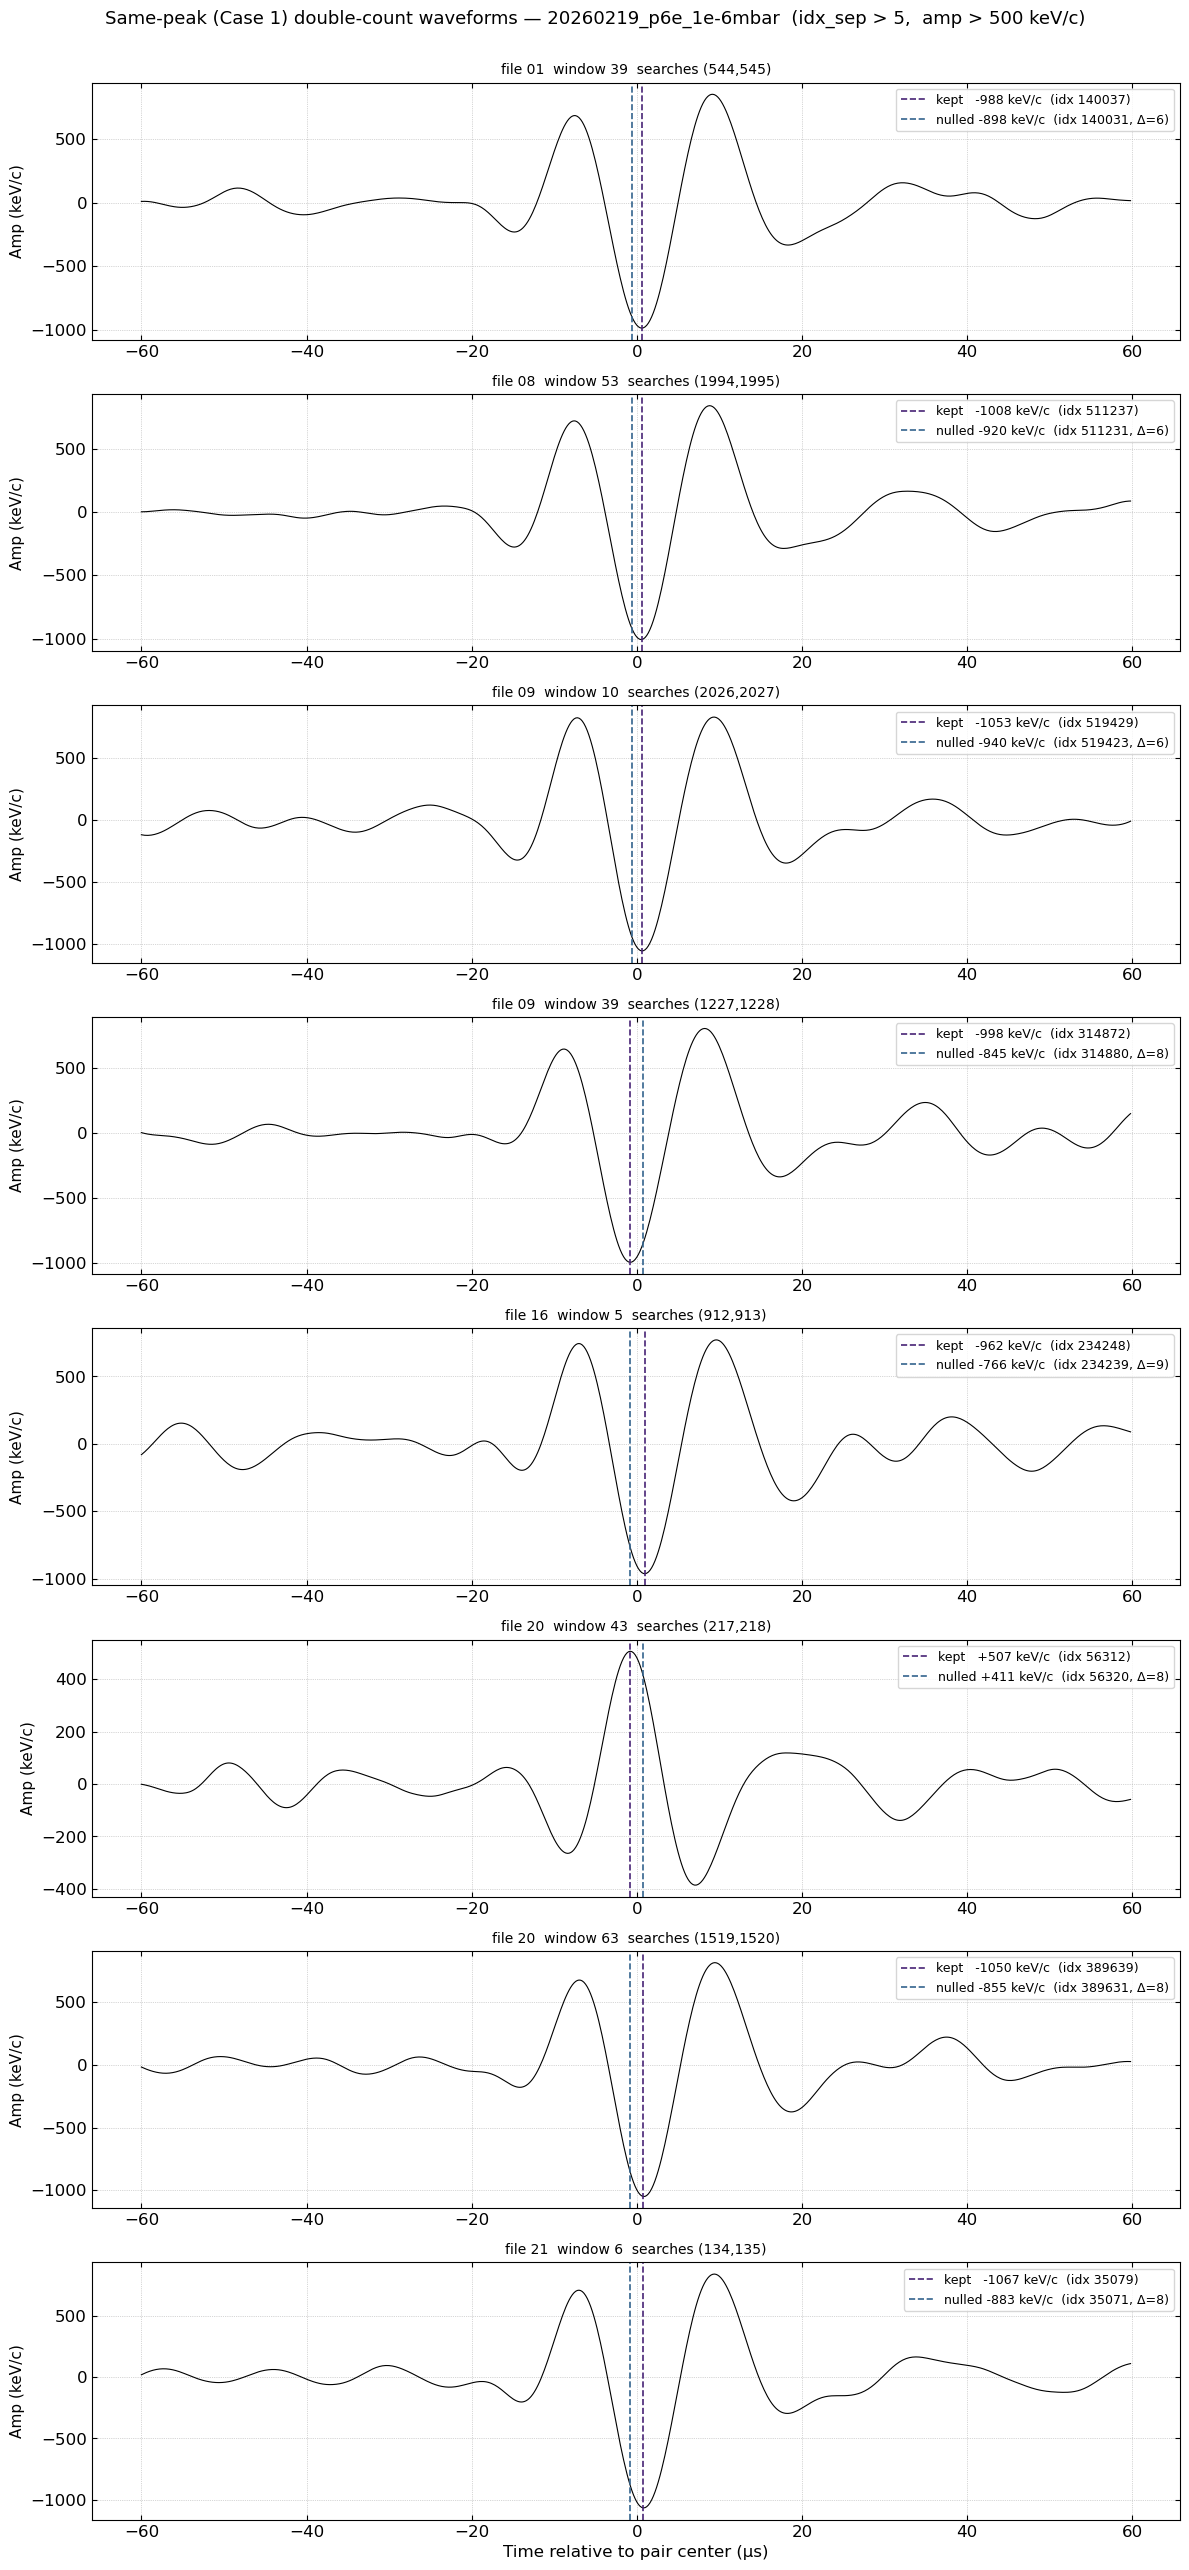

In [7]:
# Plot up to 8 same-peak (Case 1) double-count waveforms.
# Each panel shows amp_lp in keV/c over ±300 samples around the pair.
# Blue dashed line   = kept detection   (larger |amplitude|)
# Orange dashed line = nulled detection (smaller |amplitude|)

delta_threshold   = 5    # only plot pairs where idx_sep > this value
amp_threshold_kev = 500  # only plot pairs where max(|amp1|, |amp2|) > this (keV/c)

n_plot   = 8
half_win = 300   # samples to show on each side of the pair centre

pairs_to_plot = [
    p for p in all_pairs
    if p['case'] in ('same_peak', 'both')
    and p['idx_sep'] > delta_threshold
    and max(abs(p['amp1_kev']), abs(p['amp2_kev'])) > amp_threshold_kev
]
pairs_to_plot = pairs_to_plot[:n_plot]
print(f'{len(pairs_to_plot)} same-peak pairs with idx_sep > {delta_threshold} '
      f'and max amp > {amp_threshold_kev} keV/c  (showing up to {n_plot})')

if not pairs_to_plot:
    print('No pairs to plot.')
else:
    fig, axes = plt.subplots(len(pairs_to_plot), 1,
                             figsize=(12, 3.2 * len(pairs_to_plot)), sharex=False)
    if len(pairs_to_plot) == 1:
        axes = [axes]

    for ax, pair in zip(axes, pairs_to_plot):
        dtt, amp_lp = recon_window(pair['file_idx'], pair['window_j'])
        idx1, idx2 = pair['local_idx1'], pair['local_idx2']

        centre = (idx1 + idx2) // 2
        i0 = max(lb, centre - half_win)
        i1 = min(analysis_window_length, centre + half_win)

        tt      = (np.arange(i0, i1) - centre) * dtt * 1e6   # µs relative to centre
        amp_seg = amp_lp[i0:i1] * amp2kev

        ax.plot(tt, amp_seg, color='k', linewidth=0.8)

        if abs(pair['amp1_kev']) >= abs(pair['amp2_kev']):
            kept_idx, kept_amp     = idx1, pair['amp1_kev']
            nulled_idx, nulled_amp = idx2, pair['amp2_kev']
        else:
            kept_idx, kept_amp     = idx2, pair['amp2_kev']
            nulled_idx, nulled_amp = idx1, pair['amp1_kev']

        ax.axvline((kept_idx   - centre) * dtt * 1e6, color='C0', linestyle='--', linewidth=1.2,
                   label=f'kept   {kept_amp:+.0f} keV/c  (idx {kept_idx})')
        ax.axvline((nulled_idx - centre) * dtt * 1e6, color='C1', linestyle='--', linewidth=1.2,
                   label=f'nulled {nulled_amp:+.0f} keV/c  (idx {nulled_idx}, Δ={pair["idx_sep"]})')

        ax.set_ylabel('Amp (keV/c)', fontsize=11)
        ax.legend(fontsize=9, loc='upper right')
        ax.grid(which='both', ls=':', linewidth=0.5)
        ax.set_title(
            f'file {pair["file_idx"]:02d}  window {pair["window_j"]}  '
            f'searches ({pair["search_k1"]},{pair["search_k2"]})',
            fontsize=10
        )

    axes[-1].set_xlabel('Time relative to pair center (µs)', fontsize=12)
    fig.suptitle(
        f'Same-peak (Case 1) double-count waveforms — {dataset}  '
        f'(idx_sep > {delta_threshold},  amp > {amp_threshold_kev} keV/c)',
        fontsize=13, y=1.002,
    )
    fig.tight_layout()

#### Validate opposite-sign double-count removal

same_peak threshold  : 25 samples
peak_trough threshold: 85 samples  (17.0 µs)

Pairs caught:
  same_peak only      :  41749
  peak_trough only    :  17797  ← new opposite-sign condition
  both conditions     :      0
  total               :  59546


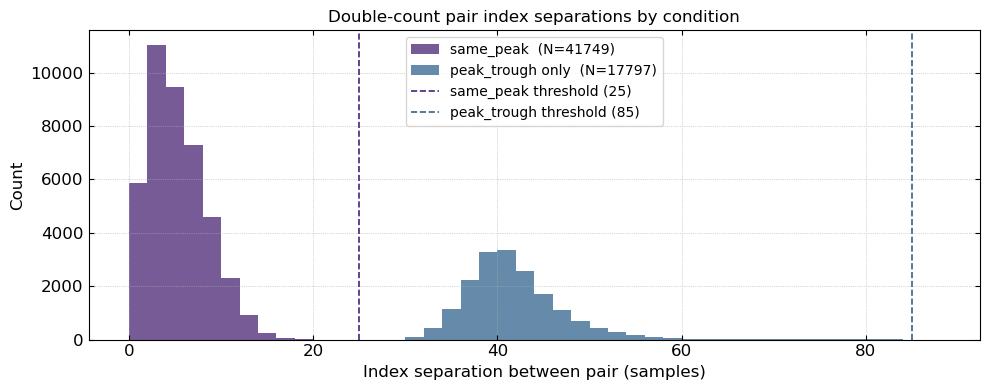

In [8]:
# ── Count pairs caught by each condition ─────────────────────────────────
# all_pairs already contains both cases from find_doublecounts_in_file.
import importlib
import recon_histograms as rh
importlib.reload(rh)

same_idx_thr = rh.doublecount_idx_thr
opp_idx_thr  = rh.doublecount_opp_sign_idx_thr

n_same_only = sum(1 for p in all_pairs if p['case'] == 'same_peak')
n_opp_only  = sum(1 for p in all_pairs if p['case'] == 'peak_trough')
n_both      = sum(1 for p in all_pairs if p['case'] == 'both')
total_caught = len(all_pairs)

print(f'same_peak threshold  : {same_idx_thr} samples')
print(f'peak_trough threshold: {opp_idx_thr} samples  ({opp_idx_thr/5e6*1e6:.1f} µs)\n')
print(f'Pairs caught:')
print(f'  same_peak only      : {n_same_only:6d}')
print(f'  peak_trough only    : {n_opp_only:6d}  ← new opposite-sign condition')
print(f'  both conditions     : {n_both:6d}')
print(f'  total               : {total_caught:6d}')

# ── Index-separation histogram split by condition ─────────────────────────
sep_same = np.array([p['idx_sep'] for p in all_pairs if p['case'] in ('same_peak', 'both')])
sep_opp  = np.array([p['idx_sep'] for p in all_pairs if p['case'] == 'peak_trough'])

bins = np.arange(0, opp_idx_thr + 5, 2)
hh_s, _ = np.histogram(sep_same, bins=bins)
hh_o, _ = np.histogram(sep_opp,  bins=bins)

fig, ax = plt.subplots(figsize=(10, 4))
ax.stairs(hh_s, bins, fill=True, alpha=0.75, color='C0',
          label=f'same_peak  (N={len(sep_same)})')
ax.stairs(hh_o, bins, fill=True, alpha=0.75, color='C1',
          label=f'peak_trough only  (N={len(sep_opp)})')
ax.axvline(same_idx_thr, color='C0', ls='--', lw=1.2,
           label=f'same_peak threshold ({same_idx_thr})')
ax.axvline(opp_idx_thr,  color='C1', ls='--', lw=1.2,
           label=f'peak_trough threshold ({opp_idx_thr})')
ax.set_xlabel('Index separation between pair (samples)', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.legend(fontsize=10)
ax.set_title('Double-count pair index separations by condition', fontsize=12)
ax.grid(ls=':', lw=0.5)
fig.tight_layout()

# Collect up to 8 peak_trough pairs for waveform plotting below
opp_pairs = [p for p in all_pairs if p['case'] in ('peak_trough', 'both')][:8]

Plotting 8 opposite-sign (peak + trough) pairs


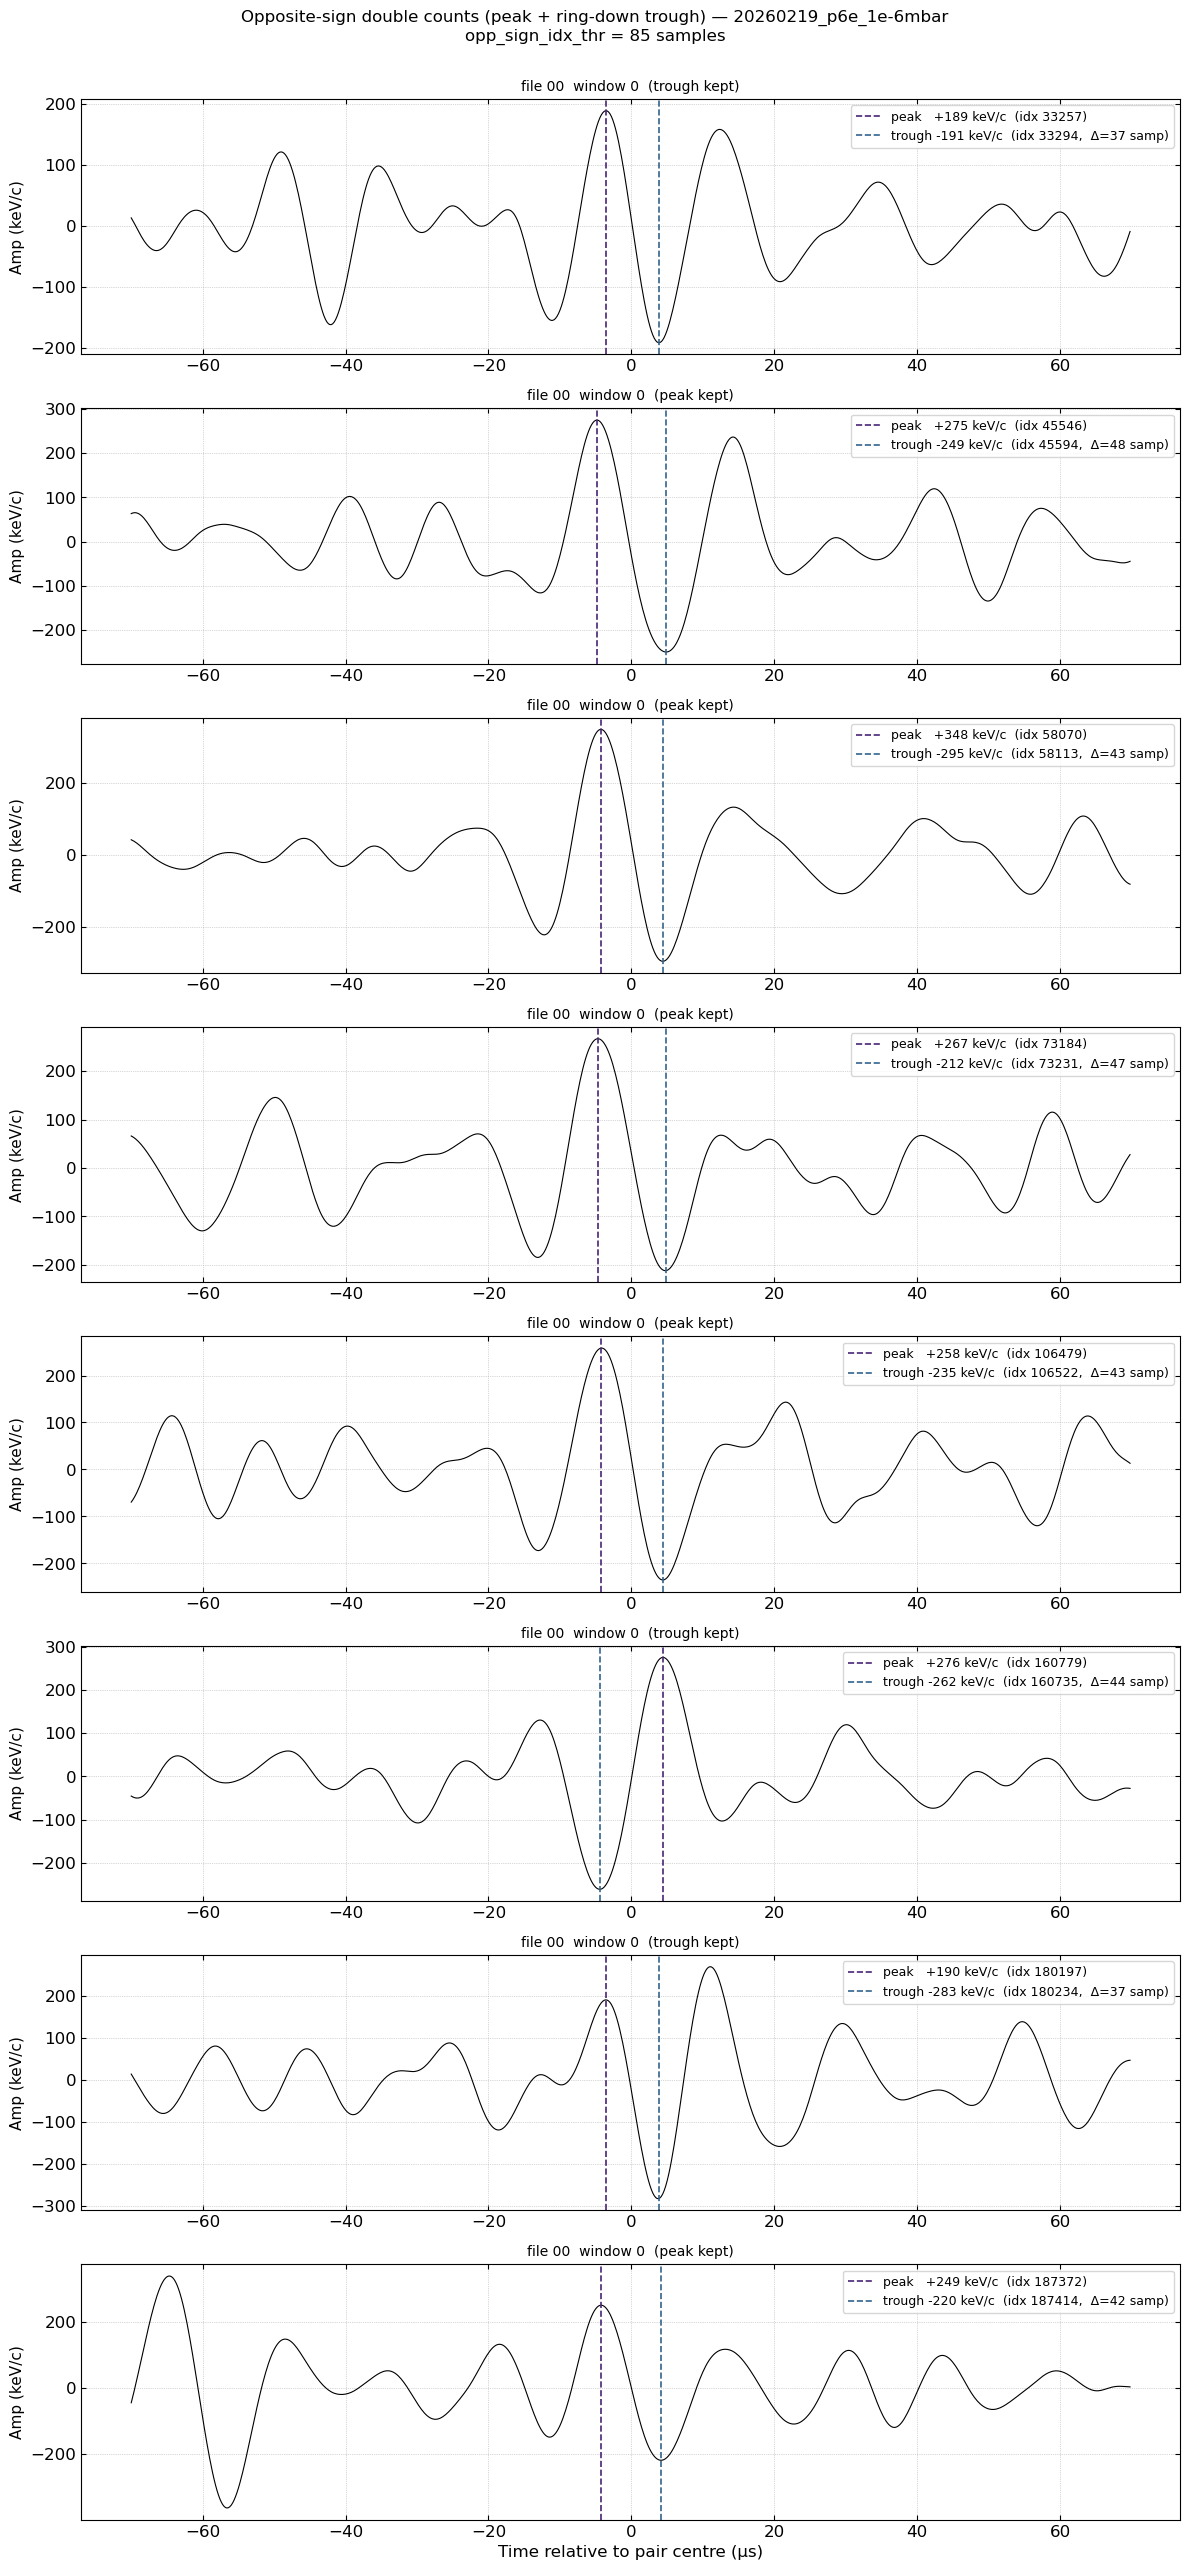

In [17]:
# ── Waveforms of peak_trough pairs (new condition) ────────────────────────
# Blue dashed  = positive peak (kept — larger |amp|)
# Orange dashed = negative trough (nulled)

n_ex = len(opp_pairs)
print(f'Plotting {n_ex} opposite-sign (peak + trough) pairs')

if not opp_pairs:
    print('No peak_trough pairs found with current threshold.')
else:
    half_win = 350
    fig, axes = plt.subplots(n_ex, 1, figsize=(12, 3.2 * n_ex), sharex=False)
    if n_ex == 1:
        axes = [axes]

    for ax, pair in zip(axes, opp_pairs):
        dtt, amp_lp = recon_window(pair['file_idx'], pair['window_j'])
        idx1, idx2  = pair['local_idx1'], pair['local_idx2']

        centre = (idx1 + idx2) // 2
        i0 = max(lb, centre - half_win)
        i1 = min(analysis_window_length, centre + half_win)
        tt_us   = (np.arange(i0, i1) - centre) * dtt * 1e6
        amp_seg = amp_lp[i0:i1] * amp2kev

        ax.plot(tt_us, amp_seg, 'k', lw=0.8)

        # Positive detection = peak, negative = trough
        if pair['amp1_kev'] >= 0:
            peak_idx, peak_amp     = idx1, pair['amp1_kev']
            trough_idx, trough_amp = idx2, pair['amp2_kev']
        else:
            peak_idx, peak_amp     = idx2, pair['amp2_kev']
            trough_idx, trough_amp = idx1, pair['amp1_kev']

        kept   = peak_idx   if abs(pair['amp1_kev']) >= abs(pair['amp2_kev']) else trough_idx
        nulled = trough_idx if kept == peak_idx else peak_idx

        ax.axvline((peak_idx   - centre) * dtt * 1e6, color='C0', ls='--', lw=1.2,
                   label=f'peak   {peak_amp:+.0f} keV/c  (idx {peak_idx})')
        ax.axvline((trough_idx - centre) * dtt * 1e6, color='C1', ls='--', lw=1.2,
                   label=f'trough {trough_amp:+.0f} keV/c  (idx {trough_idx},  Δ={pair["idx_sep"]} samp)')

        ax.set_ylabel('Amp (keV/c)', fontsize=11)
        ax.legend(fontsize=9, loc='upper right')
        ax.grid(ls=':', lw=0.5)
        ax.set_title(
            f'file {pair["file_idx"]:02d}  window {pair["window_j"]}  '
            f'({"peak kept" if kept == peak_idx else "trough kept"})',
            fontsize=10,
        )

    axes[-1].set_xlabel('Time relative to pair centre (µs)', fontsize=12)
    fig.suptitle(
        f'Opposite-sign double counts (peak + ring-down trough) — {dataset}\n'
        f'opp_sign_idx_thr = {opp_idx_thr} samples',
        fontsize=12, y=1.002,
    )
    fig.tight_layout()

#### Validate calibration pulse flagging

In [ ]:
importlib.reload(rh)

# Parameters from rh
cal_amp_thr = rh.cal_pulse_amp_thr_kev    # 700 keV/c
cal_offset  = rh.cal_pulse_offset         # 20 samples
cal_win     = rh.search_window_length     # 256 samples

# ── Scan all files ─────────────────────────────────────────────────────────
# Preprocessing applied before cal-pulse flagging, matching get_summed_histogram:
#   1. chi2 cut              — null waveforms with poor pulse-shape match
#   2. double-count removal  — null the smaller detection of each pair
#   3. flag_cal_pulses       — timing + amplitude coincidence with injected pulses
file_stats = []
for file_idx in range(nfiles):
    fpath = os.path.join(
        processed_data_dir, sphere, data_type, dataset,
        f'{file_prefix}{file_idx}_processed.hdf5'
    )
    with h5py.File(fpath, 'r') as f:
        amps_raw       = f['data_processed']['amplitude'][:]
        idx_in_window  = f['data_processed']['idx_in_window'][:]
        good_detection = f['data_processed']['good_detection'][:]
        noise_level    = f['data_processed']['noise_level_amp'][:]
        chi2           = f['data_processed']['chisquare'][:]
        pulse_indices  = f['data_processed']['pulse_indices'][:]

    noise_ok    = noise_level * amp2kev < noise_threshold_kev
    good_window = good_detection & noise_ok
    n_searches  = amps_raw.shape[1]
    good_mask   = np.tile(good_window[:, np.newaxis], (1, n_searches))

    # Step 1: chi2 cut
    amps = np.array(amps_raw, dtype=np.float64)
    amps[chi2 >= rh.chi2_threshold] = np.nan

    # Step 2: double-count removal
    amps = rh.throw_away_doublecounts(amps, good_window, idx_in_window)

    # Step 3: cal-pulse flagging on the cleaned amplitudes
    is_cal    = rh.flag_cal_pulses(idx_in_window, pulse_indices, amps)
    above_amp = np.abs(amps) * amp2kev > cal_amp_thr

    file_stats.append(dict(
        file_idx       = file_idx,
        pulse_indices  = pulse_indices,
        amps           = amps,          # chi2-cut + double-count-removed
        idx_in_window  = idx_in_window,
        good_window    = good_window,
        good_mask      = good_mask,
        is_cal         = is_cal,
        n_cal_triggers = pulse_indices.size,
        n_large_amp    = int((above_amp & good_mask).sum()),
        n_flagged      = int((is_cal & good_mask).sum()),
    ))

total_triggers = sum(s['n_cal_triggers'] for s in file_stats)
total_large    = sum(s['n_large_amp']    for s in file_stats)
total_flagged  = sum(s['n_flagged']      for s in file_stats)

print(f'Dataset : {dataset}  ({nfiles} files)')
print(f'Cal triggers in pulse_indices             : {total_triggers}')
print(f'Detections above {cal_amp_thr:.0f} keV/c (after preprocessing) : {total_large}')
print(f'Flagged by flag_cal_pulses                : {total_flagged}')
if total_triggers > 0:
    print(f'Flagged / triggers ratio                  : {total_flagged / total_triggers:.2f}  (expect ≈ 1 without data cuts)')
if total_triggers == 0:
    print('\n⚠  No pulse_indices found — switch to a dataset with injected calibration pulses.')

Dataset : 20260219_p6e_1e-6mbar  (25 files)
Cal triggers in pulse_indices             : 559
Detections above 700 keV/c (after preprocessing) : 217
Flagged by flag_cal_pulses                : 217
Flagged / triggers ratio                  : 0.39  (expect ≈ 1)


Large-amp detections with a valid trigger to the left:
  Flagged   : 217
  Unflagged : 2498


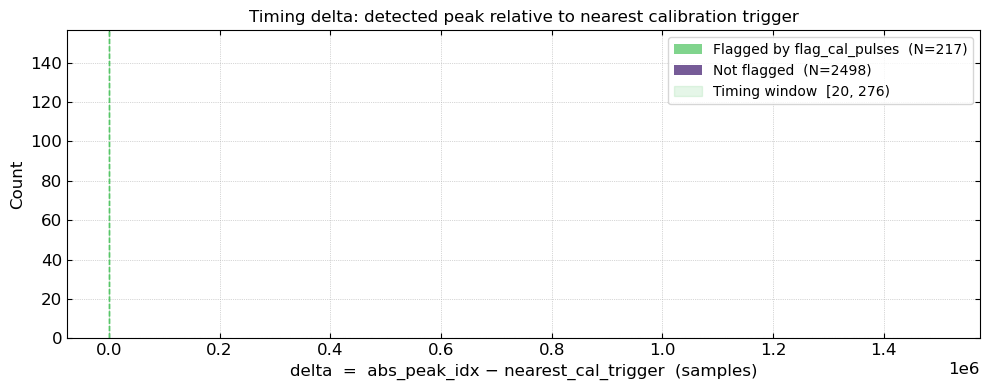

In [11]:
# ── Timing-delta histogram ────────────────────────────────────────────────
# For every large-amplitude detection in a good window, compute
#   delta = abs_peak_idx − nearest_cal_trigger_to_the_left
# Flagged detections should cluster inside [cal_offset, cal_offset + cal_win].

deltas_flagged_list, deltas_unflagged_list = [], []

for s in file_stats:
    if s['n_cal_triggers'] == 0:
        continue

    n_windows  = s['idx_in_window'].shape[0]
    win_offsets = np.arange(n_windows, dtype=np.int64) * analysis_window_length
    abs_idx_flat = (win_offsets[:, np.newaxis] + s['idx_in_window'].astype(np.int64)).ravel()

    sorted_pulses = np.sort(s['pulse_indices'].astype(np.int64))
    pos   = np.searchsorted(sorted_pulses, abs_idx_flat, side='right') - 1
    valid = (pos >= 0) & (pos < sorted_pulses.size)
    delta = np.where(valid,
                     abs_idx_flat - sorted_pulses[np.clip(pos, 0, sorted_pulses.size - 1)],
                     np.int64(-1))
    delta = delta.reshape(s['idx_in_window'].shape)

    above_half = np.abs(s['amps']) * amp2kev > cal_amp_thr / 2
    mask = above_half & s['good_mask'] & (delta >= 0)

    deltas_flagged_list.append(delta[mask &  s['is_cal']])
    deltas_unflagged_list.append(delta[mask & ~s['is_cal']])

deltas_flagged   = np.concatenate(deltas_flagged_list)   if deltas_flagged_list   else np.array([], dtype=np.int64)
deltas_unflagged = np.concatenate(deltas_unflagged_list) if deltas_unflagged_list else np.array([], dtype=np.int64)

print(f'Large-amp detections with a valid trigger to the left:')
print(f'  Flagged   : {len(deltas_flagged)}')
print(f'  Unflagged : {len(deltas_unflagged)}')

all_deltas = np.concatenate([deltas_flagged, deltas_unflagged])
bins = np.arange(-20, (all_deltas.max() if all_deltas.size else 600) + 24, 4)

hh_f, _ = np.histogram(deltas_flagged,   bins=bins)
hh_u, _ = np.histogram(deltas_unflagged, bins=bins)

fig, ax = plt.subplots(figsize=(10, 4))
ax.stairs(hh_f, bins, fill=True, alpha=0.75, color='C3',
          label=f'Flagged by flag_cal_pulses  (N={len(deltas_flagged)})')
ax.stairs(hh_u, bins, fill=True, alpha=0.75, color='C0',
          label=f'Not flagged  (N={len(deltas_unflagged)})')
ax.axvspan(cal_offset, cal_offset + cal_win, alpha=0.15, color='C3',
           label=f'Timing window  [{cal_offset}, {cal_offset + cal_win})')
ax.axvline(cal_offset,           color='C3', lw=1.0, ls='--')
ax.axvline(cal_offset + cal_win, color='C3', lw=1.0, ls='--')

ax.set_xlabel('delta  =  abs_peak_idx − nearest_cal_trigger  (samples)', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.legend(fontsize=10)
ax.set_title('Timing delta: detected peak relative to nearest calibration trigger', fontsize=12)
ax.grid(ls=':', lw=0.5)
fig.tight_layout()

Plotting 6 flagged cal-pulse waveforms


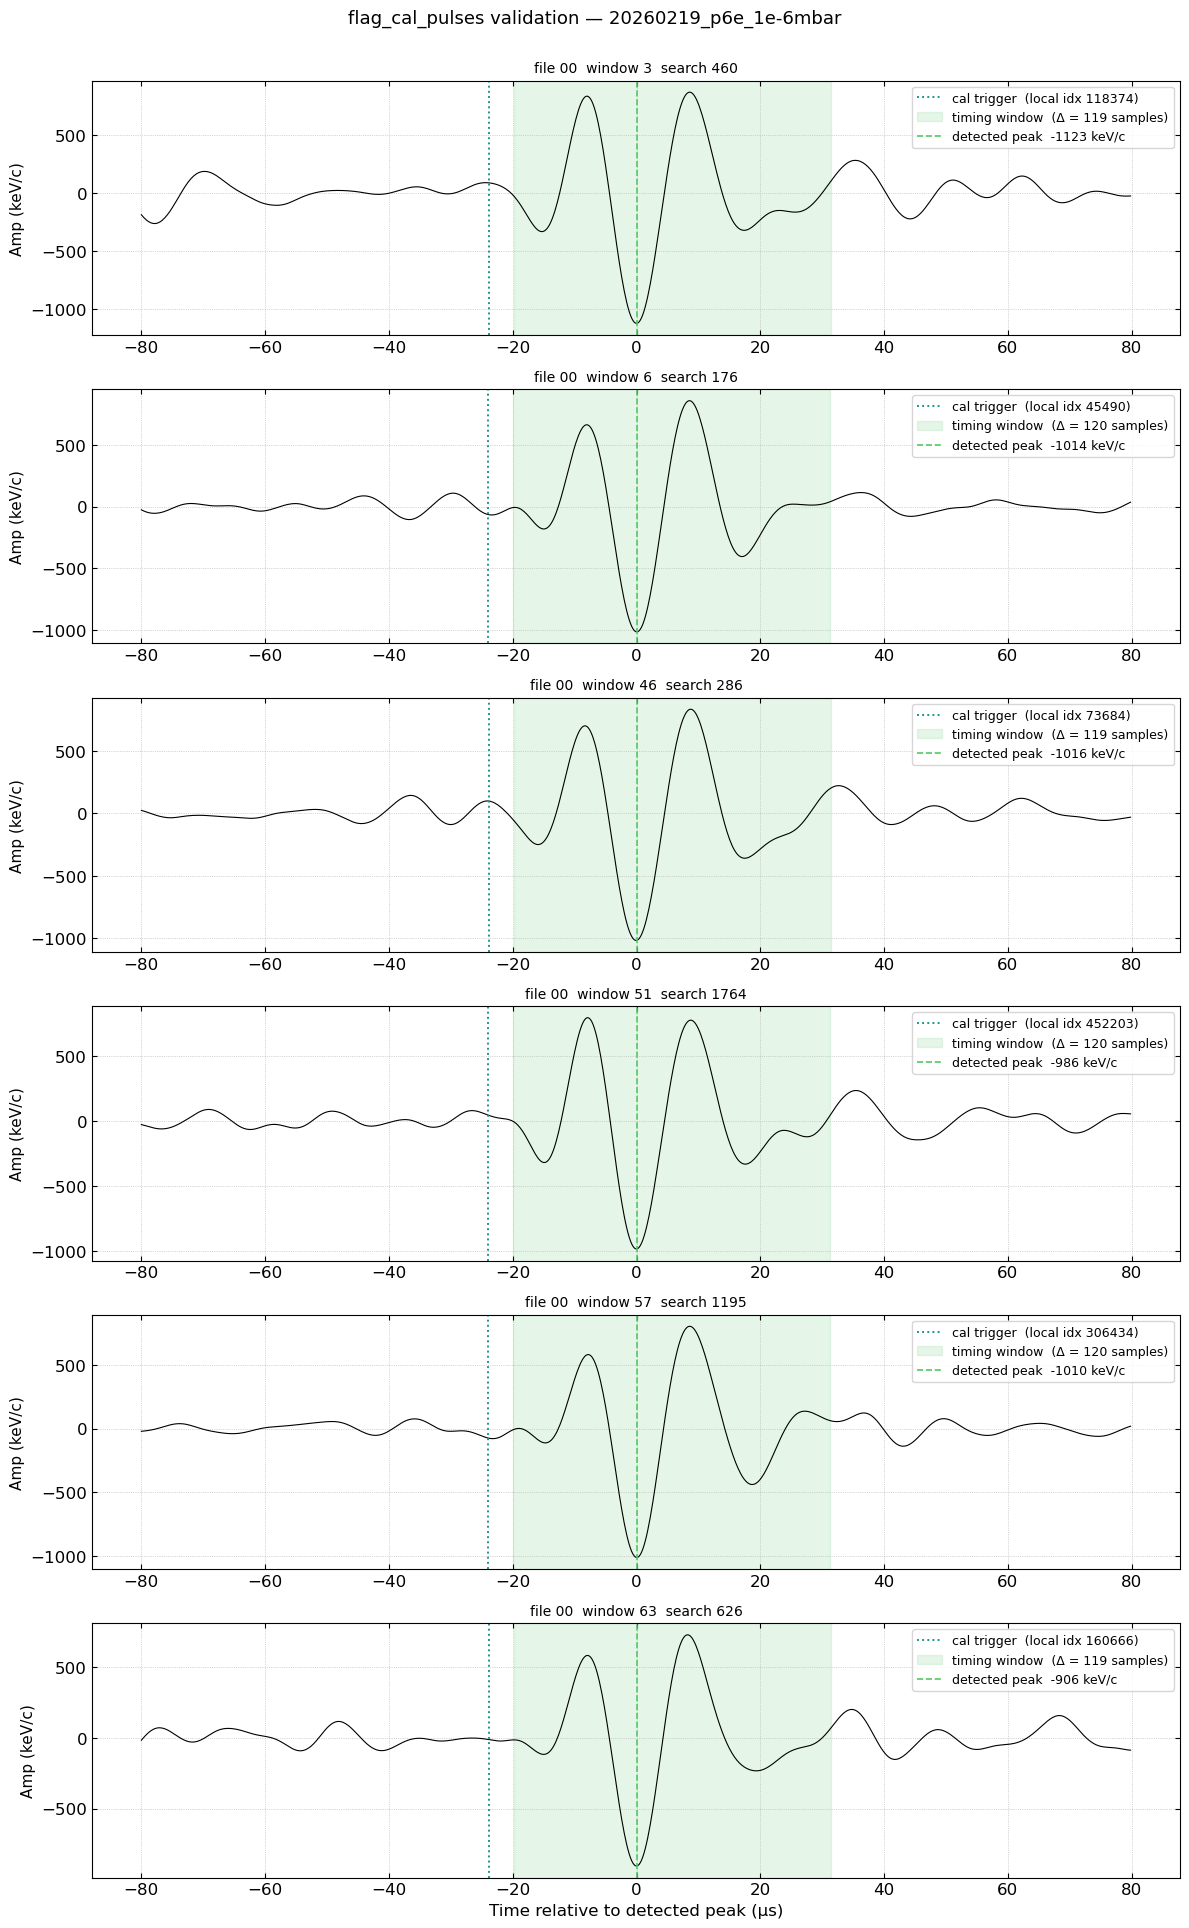

In [12]:
# ── Waveforms of flagged cal-pulse detections ─────────────────────────────
# Each panel: reconstructed amp_lp around a flagged detection.
#   Green dotted  = cal trigger position
#   Red shaded    = expected timing window [trigger + offset, trigger + offset + cal_win)
#   Orange dashed = detected peak

n_wf_plot = 6
cal_examples = []

for s in file_stats:
    if len(cal_examples) >= n_wf_plot:
        break
    if s['n_cal_triggers'] == 0:
        continue

    n_windows  = s['idx_in_window'].shape[0]
    sorted_pulses = np.sort(s['pulse_indices'].astype(np.int64))
    win_offsets   = np.arange(n_windows, dtype=np.int64) * analysis_window_length

    for j, k in np.argwhere(s['is_cal'] & s['good_mask']):
        if len(cal_examples) >= n_wf_plot:
            break
        local_peak = int(s['idx_in_window'][j, k])
        abs_peak   = int(win_offsets[j]) + local_peak
        pos        = int(np.searchsorted(sorted_pulses, abs_peak, side='right')) - 1
        if pos < 0:
            continue
        nearest_abs   = int(sorted_pulses[pos])
        nearest_local = nearest_abs - int(win_offsets[j])
        cal_examples.append(dict(
            file_idx      = s['file_idx'],
            window_j      = int(j),
            search_k      = int(k),
            local_peak    = local_peak,
            local_trigger = nearest_local,
            delta         = abs_peak - nearest_abs,
            amp_kev       = float(s['amps'][j, k]) * amp2kev,
        ))

print(f'Plotting {len(cal_examples)} flagged cal-pulse waveforms')
if not cal_examples:
    print('No flagged examples found — dataset has no pulse_indices.')
else:
    half_win = 400
    n_ex = len(cal_examples)
    fig, axes = plt.subplots(n_ex, 1, figsize=(12, 3.2 * n_ex), sharex=False)
    if n_ex == 1:
        axes = [axes]

    for ax, ex in zip(axes, cal_examples):
        dtt, amp_lp   = recon_window(ex['file_idx'], ex['window_j'])
        centre        = ex['local_peak']
        i0 = max(lb, centre - half_win)
        i1 = min(analysis_window_length, centre + half_win)
        tt_us = (np.arange(i0, i1) - centre) * dtt * 1e6

        ax.plot(tt_us, amp_lp[i0:i1] * amp2kev, 'k', lw=0.8)

        # Cal trigger and timing window (converted to µs relative to detected peak)
        t_trig = (ex['local_trigger'] - centre) * dtt * 1e6
        t_win0 = (ex['local_trigger'] + cal_offset - centre) * dtt * 1e6
        t_win1 = (ex['local_trigger'] + cal_offset + cal_win - centre) * dtt * 1e6
        ax.axvline(t_trig, color='C2', lw=1.4, ls=':',
                   label=f'cal trigger  (local idx {ex["local_trigger"]})')
        ax.axvspan(t_win0, t_win1, alpha=0.15, color='C3',
                   label=f'timing window  (Δ = {ex["delta"]} samples)')

        # Detected peak
        ax.axvline(0, color='C3', lw=1.2, ls='--',
                   label=f'detected peak  {ex["amp_kev"]:+.0f} keV/c')

        ax.set_ylabel('Amp (keV/c)', fontsize=11)
        ax.legend(fontsize=9, loc='upper right')
        ax.grid(ls=':', lw=0.5)
        ax.set_title(
            f'file {ex["file_idx"]:02d}  window {ex["window_j"]}  search {ex["search_k"]}',
            fontsize=10
        )

    axes[-1].set_xlabel('Time relative to detected peak (µs)', fontsize=12)
    fig.suptitle(f'flag_cal_pulses validation — {dataset}', fontsize=13, y=1.002)
    fig.tight_layout()

Total triggers tracked: 559

  flagged                  :   217  (38.8%)
  bad_window               :   146  (26.1%)
  bad_window_lowamp        :   143  (25.6%)
  low_amp                  :    53  (9.5%)
  no_detect                :     0  (0.0%)
  beyond_data              :     0  (0.0%)


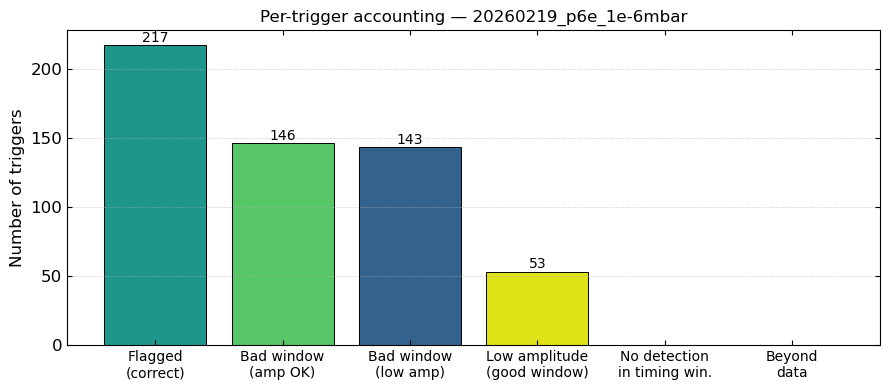

In [15]:
# ── Per-trigger accounting ────────────────────────────────────────────────
# Classify every entry in pulse_indices across all files into one of:
#   flagged          — timing match + amp OK + good window  ✓
#   bad_window       — timing match + amp OK, but window failed quality cuts
#   low_amp          — timing match, good window, but |amp| < cal_amp_thr
#                      (includes detections nulled by chi2 cut or double-count removal)
#   bad_window_lowamp— timing match, amp low, AND bad window
#   no_detect        — no detection found in timing window (trigger near window edge)
#   beyond_data      — trigger_abs // analysis_window_length >= n_windows
#
# Note: s['amps'] has NaN for chi2-cut / double-count-removed entries.
#   np.fmax is used so a NaN in one sub-window does not hide a valid detection
#   in the adjacent sub-window.

from collections import Counter

trigger_cats   = []   # category string per trigger
trigger_files  = []   # file_idx per trigger
trigger_windows= []   # window_j per trigger (int or None)
trigger_amps   = []   # best_amp_kev per trigger

for s in file_stats:
    if s['n_cal_triggers'] == 0:
        continue

    n_windows  = s['idx_in_window'].shape[0]
    n_searches = s['idx_in_window'].shape[1]   # use actual shape, not a hardcoded constant
    win_offsets = np.arange(n_windows, dtype=np.int64) * analysis_window_length
    p_all       = s['pulse_indices'].astype(np.int64)
    wj_all      = p_all // analysis_window_length

    # ── beyond-data triggers ─────────────────────────────
    beyond = wj_all >= n_windows
    n_beyond = int(beyond.sum())
    trigger_cats   += ['beyond_data'] * n_beyond
    trigger_files  += [s['file_idx']] * n_beyond
    trigger_windows+= [None] * n_beyond
    trigger_amps   += [np.nan] * n_beyond

    # ── valid triggers ────────────────────────────────────
    p_v       = p_all[~beyond]
    wj_v      = wj_all[~beyond].astype(int)
    p_local_v = p_v - win_offsets[wj_v]   # position of trigger within its analysis window
    good_win_v= s['good_window'][wj_v]

    # Sub-window index containing the expected cal-pulse peak.
    # Search sub-windows start at lb (prepulse region is excluded), so
    # sub-window k covers [lb + k*search_window_length, lb + (k+1)*search_window_length).
    k0_v   = ((p_local_v + cal_offset - lb) // search_window_length).astype(int)
    in0    = (k0_v >= 0) & (k0_v < n_searches)
    k0_safe = np.clip(k0_v, 0, n_searches - 1)

    # Also check the adjacent sub-window: a cal pulse near a sub-window boundary
    # may have its kept detection in k1 (if the k0 detection was nulled).
    k1_v   = k0_v + 1
    in1    = (k1_v >= 0) & (k1_v < n_searches)
    k1_safe = np.clip(k1_v, 0, n_searches - 1)

    # idx_in_window stores the analysis-window-local peak position (0 to analysis_window_length-1)
    idx0 = s['idx_in_window'][wj_v, k0_safe].astype(np.int64)
    amp0 = s['amps'][wj_v, k0_safe]   # may be NaN if chi2-cut or double-count-removed
    d0   = idx0 - p_local_v
    t0   = in0 & (d0 >= cal_offset) & (d0 < cal_offset + cal_win)

    idx1 = s['idx_in_window'][wj_v, k1_safe].astype(np.int64)
    amp1 = s['amps'][wj_v, k1_safe]   # may be NaN
    d1   = idx1 - p_local_v
    t1   = in1 & (d1 >= cal_offset) & (d1 < cal_offset + cal_win)

    timing_v = t0 | t1
    # np.fmax ignores NaN: if one sub-window was nulled, the other's amplitude is used
    best_amp_kev_v = np.fmax(
        np.where(t0, np.abs(amp0), 0.0),
        np.where(t1, np.abs(amp1), 0.0),
    ) * amp2kev
    amp_ok_v = best_amp_kev_v > cal_amp_thr

    cats_v = np.where(~timing_v,               'no_detect',
             np.where(amp_ok_v &  good_win_v,  'flagged',
             np.where(amp_ok_v & ~good_win_v,  'bad_window',
             np.where(~amp_ok_v & good_win_v,  'low_amp',
                                               'bad_window_lowamp'))))

    trigger_cats    += cats_v.tolist()
    trigger_files   += [s['file_idx']] * len(p_v)
    trigger_windows += wj_v.tolist()
    trigger_amps    += best_amp_kev_v.tolist()

# ── Summary ───────────────────────────────────────────────────────────────
counts = Counter(trigger_cats)
total  = len(trigger_cats)
print(f'Total triggers tracked: {total}\n')
cat_order = ['flagged', 'bad_window', 'bad_window_lowamp', 'low_amp', 'no_detect', 'beyond_data']
for cat in cat_order:
    n = counts.get(cat, 0)
    print(f'  {cat:25s}: {n:5d}  ({100*n/total:.1f}%)')

# ── Bar chart ──────────────────────────────────────────────────────────────
cat_labels = [
    'Flagged\n(correct)',
    'Bad window\n(amp OK)',
    'Bad window\n(low amp)',
    'Low amplitude\n(good window)',
    'No detection\nin timing win.',
    'Beyond\ndata',
]
cat_colors = ['C2', 'C3', 'C1', 'C9', 'C7', 'C8']
ns = [counts.get(c, 0) for c in cat_order]

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(range(len(cat_order)), ns, color=cat_colors, edgecolor='k', linewidth=0.7)
for bar, n in zip(bars, ns):
    if n > 0:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
                str(n), ha='center', va='bottom', fontsize=10)
ax.set_xticks(range(len(cat_order)))
ax.set_xticklabels(cat_labels, fontsize=10)
ax.set_ylabel('Number of triggers', fontsize=12)
ax.set_title(f'Per-trigger accounting — {dataset}', fontsize=12)
ax.grid(axis='y', ls=':', lw=0.5)
fig.tight_layout()

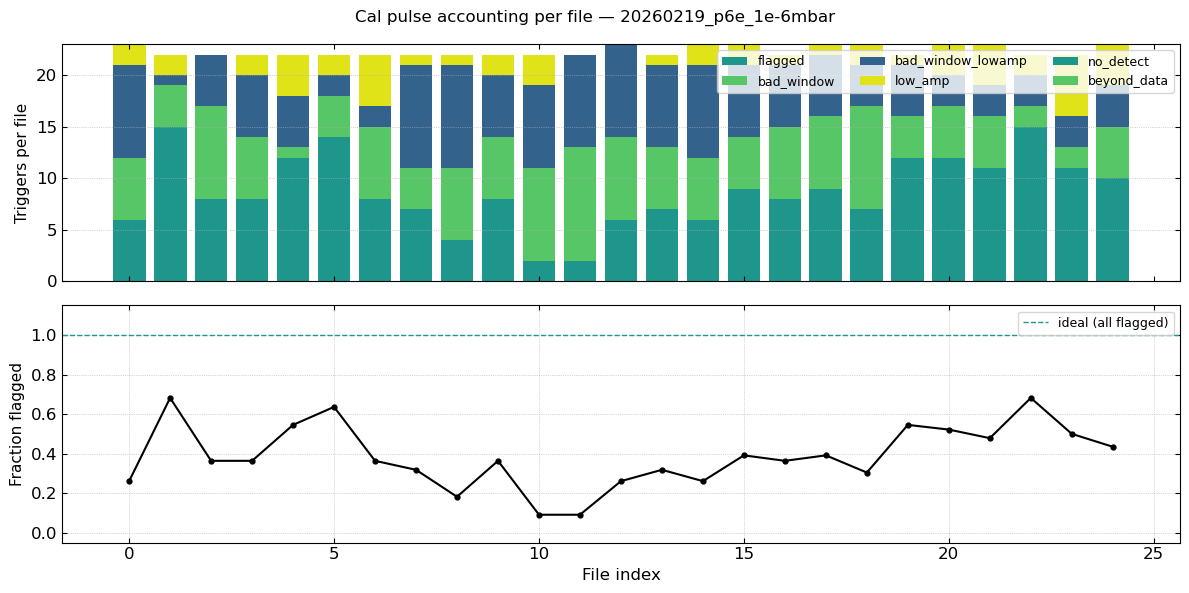

In [16]:
# ── Per-file time series ──────────────────────────────────────────────────
# Shows whether misses are clustered in particular files (sphere instability,
# noisy period, etc.) vs evenly distributed.

trigger_files_arr = np.array(trigger_files)
trigger_cats_arr  = np.array(trigger_cats)
file_indices      = np.arange(nfiles)

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

# Top panel: stacked bar per category per file
bottom = np.zeros(len(file_indices))
for cat, color in zip(
    ['flagged', 'bad_window', 'bad_window_lowamp', 'low_amp', 'no_detect', 'beyond_data'],
    ['C2',      'C3',         'C1',                 'C9',      'C7',        'C8'],
):
    yy = np.array([(trigger_cats_arr[trigger_files_arr == i] == cat).sum()
                   for i in file_indices])
    axes[0].bar(file_indices, yy, bottom=bottom, color=color, label=cat,
                edgecolor='none', width=0.8)
    bottom += yy

axes[0].set_ylabel('Triggers per file', fontsize=11)
axes[0].legend(fontsize=9, loc='upper right', ncol=3)
axes[0].grid(axis='y', ls=':', lw=0.5)

# Bottom panel: fraction flagged per file
total_per_file   = np.array([(trigger_files_arr == i).sum()                          for i in file_indices])
flagged_per_file = np.array([(trigger_cats_arr[trigger_files_arr == i] == 'flagged').sum()
                              for i in file_indices])
frac = np.where(total_per_file > 0, flagged_per_file / total_per_file, np.nan)

axes[1].plot(file_indices, frac, 'k.-', markersize=7)
axes[1].axhline(1.0, color='C2', ls='--', lw=1.0, label='ideal (all flagged)')
axes[1].set_ylim(-0.05, 1.15)
axes[1].set_ylabel('Fraction flagged', fontsize=11)
axes[1].set_xlabel('File index', fontsize=12)
axes[1].legend(fontsize=9)
axes[1].grid(ls=':', lw=0.5)

fig.suptitle(f'Cal pulse accounting per file — {dataset}', fontsize=12)
fig.tight_layout()